In [3]:
import pandas as pd
import numpy as np

# 1. Define the column names for the NSL-KDD dataset
# These names correspond to the 41 features + label + difficulty_level
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

# 2. Load the datasets
# We assume the files are in the same directory as your notebook
print("Loading datasets...")

try:
    # Load Training Data
    train_df = pd.read_csv('KDDTrain+.txt', names=columns)
    print(" Training Set loaded successfully!")
    
    # Load Testing Data
    test_df = pd.read_csv('KDDTest+.txt', names=columns)
    print(" Testing Set loaded successfully!")

    # 3. Verify Data
    print(f"\nTraining Set Shape: {train_df.shape}")
    print(f"Testing Set Shape:  {test_df.shape}")
    
    # 4. Show the first few rows of the training set
    print("\nSample of Training Data:")
    display(train_df.head())

except FileNotFoundError as e:
    print(f"❌ Error: {e}")
    print("Please make sure 'KDDTrain+.txt' and 'KDDTest+.txt' are in the correct folder.")

Loading datasets...
✅ Training Set loaded successfully!
✅ Testing Set loaded successfully!

Training Set Shape: (125973, 43)
Testing Set Shape:  (22544, 43)

Sample of Training Data:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty_level
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


Checking for missing values...
Missing values in Train Set: 0
Missing values in Test Set:  0

Training Set Class Distribution:
class
Normal    67343
Attack    58630
Name: count, dtype: int64

Testing Set Class Distribution:
class
Attack    12833
Normal     9711
Name: count, dtype: int64


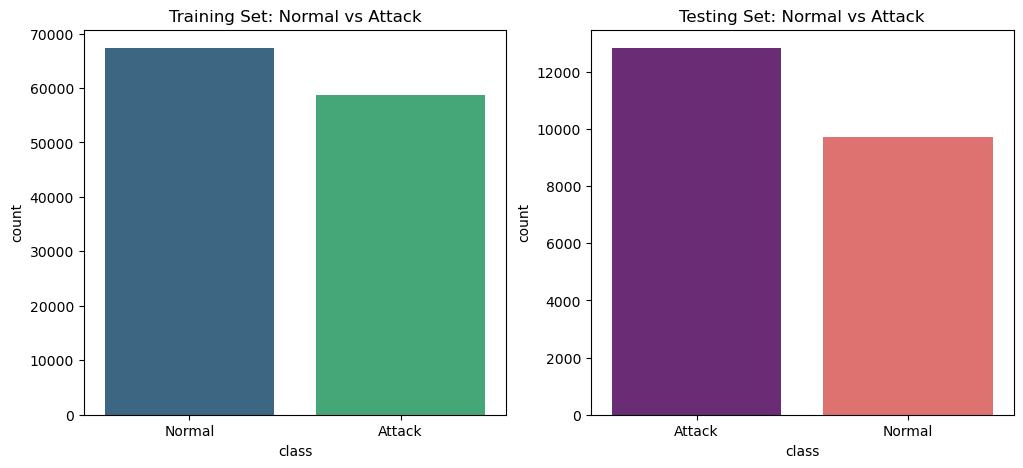

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Check for Missing Values
# It is crucial to ensure there are no empty cells in the data.
print("Checking for missing values...")
print(f"Missing values in Train Set: {train_df.isnull().sum().sum()}")
print(f"Missing values in Test Set:  {test_df.isnull().sum().sum()}")

# 2. Create Binary Class Labels
# We map 'normal' to 'Normal' and everything else to 'Attack'.
def categorize_label(x):
    if x == 'normal':
        return 'Normal'
    else:
        return 'Attack'

# Apply this new category to a new column named 'class'
train_df['class'] = train_df['label'].apply(categorize_label)
test_df['class'] = test_df['label'].apply(categorize_label)

# 3. Display the Distribution
print("\nTraining Set Class Distribution:")
print(train_df['class'].value_counts())

print("\nTesting Set Class Distribution:")
print(test_df['class'].value_counts())

# 4. Visualize the Data Balance
plt.figure(figsize=(12, 5))

# Plot Training Data
plt.subplot(1, 2, 1)
sns.countplot(x='class', data=train_df, hue='class', palette='viridis')
plt.title('Training Set: Normal vs Attack')

# Plot Testing Data
plt.subplot(1, 2, 2)
sns.countplot(x='class', data=test_df, hue='class', palette='magma')
plt.title('Testing Set: Normal vs Attack')

plt.show()

In [5]:
from sklearn.preprocessing import LabelEncoder

# 1. Drop unnecessary columns
# We drop 'label' because we created 'class'. We drop 'difficulty_level' as it's metadata.
train_df = train_df.drop(['label', 'difficulty_level'], axis=1)
test_df = test_df.drop(['label', 'difficulty_level'], axis=1)

# 2. Encode Target Variable ('class')
# Map 'Normal' -> 0 and 'Attack' -> 1
def encode_target(x):
    return 0 if x == 'Normal' else 1

train_df['target'] = train_df['class'].apply(encode_target)
test_df['target'] = test_df['class'].apply(encode_target)

# Drop the text 'class' column now that we have the numeric 'target'
train_df = train_df.drop('class', axis=1)
test_df = test_df.drop('class', axis=1)

# 3. Encode Categorical Features (Protocol, Service, Flag)
# We use LabelEncoder to turn text categories into numbers (e.g., 'tcp' -> 1).
categorical_cols = ['protocol_type', 'service', 'flag']

# Important: We fit the encoder on BOTH train and test data to ensure 
# the model knows how to handle every possible category found in both files.
for col in categorical_cols:
    le = LabelEncoder()
    # Combine data just to "learn" the categories
    combined_data = pd.concat([train_df[col], test_df[col]], axis=0)
    le.fit(combined_data)
    
    # Transform the columns
    train_df[col] = le.transform(train_df[col])
    test_df[col] = le.transform(test_df[col])

# 4. Verify Final Data Structure
print("Feature Engineering Complete!")
print(f"Final Training Set Shape: {train_df.shape}")
print(f"Final Testing Set Shape:  {test_df.shape}")

print("\nFirst 5 rows of processed Training Data:")
display(train_df.head())

Feature Engineering Complete!
Final Training Set Shape: (125973, 42)
Final Testing Set Shape:  (22544, 42)

First 5 rows of processed Training Data:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,target
0,0,1,20,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,0
1,0,2,44,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,0
2,0,1,49,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,1
3,0,1,24,9,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,0
4,0,1,24,9,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0


In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import joblib

# 1. Initialize the two models we want to compare
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100)
}

print("Training models for comparison...\n")

# 2. Train, Evaluate, and Save specific models
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    print(f"✅ {name} Accuracy: {acc:.4f}")
    
    # Save with a specific name
    if name == "Random Forest":
        joblib.dump(model, 'rf_model.pkl')
        print(f"   💾 Saved as 'rf_model.pkl'")
    elif name == "Decision Tree":
        joblib.dump(model, 'dt_model.pkl')
        print(f"   💾 Saved as 'dt_model.pkl'")

print("\n🎉 Both models have been saved successfully.")

Training models for comparison...

✅ Decision Tree Accuracy: 0.7700
   💾 Saved as 'dt_model.pkl'
✅ Random Forest Accuracy: 0.7639
   💾 Saved as 'rf_model.pkl'

🎉 Both models have been saved successfully.


In [8]:
from scapy.all import sniff, IP, TCP, UDP
import pandas as pd
import numpy as np

# 1. Define the 41 features our model expects (Must match training data exactly)
feature_columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'
]

# 2. Helper function to map ports to services (Simplified)
def get_service(pkt):
    if pkt.haslayer(TCP):
        port = pkt[TCP].dport
        if port == 80: return 'http'
        if port == 21: return 'ftp'
        if port == 22: return 'ssh'
        if port == 25: return 'smtp'
    return 'other'

# 3. Main Capture Function
def capture_traffic(packet_count=10):
    print(f"Subscribing to network traffic... Capturing {packet_count} packets.")
    
    captured_data = []
    
    # Define a callback function to process each packet
    def process_packet(pkt):
        if pkt.haslayer(IP):
            # Basic Extraction
            duration = 0  # Real-time calculation is complex, assuming 0 for single packet
            src_bytes = len(pkt[IP].payload)
            dst_bytes = 0 # Can't know response size in single packet sniffing
            
            # Protocol
            proto = 'tcp' if pkt.haslayer(TCP) else 'udp' if pkt.haslayer(UDP) else 'icmp'
            
            # Service
            service = get_service(pkt)
            
            # Create a row with all 41 columns set to 0 initially
            row = {col: 0 for col in feature_columns}
            
            # Update the fields we actually captured
            row['duration'] = duration
            row['protocol_type'] = proto
            row['service'] = service
            row['flag'] = 'SF' # Assume Normal Flag (SF = Standard Flag)
            row['src_bytes'] = src_bytes
            row['dst_bytes'] = dst_bytes
            
            captured_data.append(row)

    # Sniff packets
    sniff(prn=process_packet, count=packet_count)
    
    # Convert to DataFrame
    live_df = pd.DataFrame(captured_data)
    
    print(f"✅ Captured {len(live_df)} packets.")
    return live_df

# 4. Test the Capture
# Note: This might require Administrator/Root privileges depending on your OS.
try:
    live_data = capture_traffic(packet_count=5)
    display(live_data.head())
except Exception as e:
    print(f"❌ Error: {e}")
    print("Try running Jupyter Notebook as Administrator or check Scapy installation.")

Subscribing to network traffic... Capturing 5 packets.
✅ Captured 4 packets.


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,udp,other,SF,335,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,udp,other,SF,49,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,udp,other,SF,217,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,tcp,http,SF,32,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder

# 1. Load the Saved Models
print("Loading models...")
rf_model = joblib.load('rf_model.pkl')
dt_model = joblib.load('dt_model.pkl')
print("✅ Models loaded.")

# 2. Re-create the Encoders (The Translators)
# We need to know exactly what number 'tcp' was assigned during training.
# Since we didn't save the encoders separately, we quickly fit them again on the raw training data.
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

# Load raw training data just for the encoders
raw_train_df = pd.read_csv('KDDTrain+.txt', names=columns)

# Define the categorical columns
categorical_cols = ['protocol_type', 'service', 'flag']

# Create a dictionary to store our encoders
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    le.fit(raw_train_df[col])
    encoders[col] = le

# 3. Function to Preprocess Live Data
def preprocess_live_data(df, encoders):
    df_encoded = df.copy()
    for col, le in encoders.items():
        # Handle unknown labels (e.g., if we see a service not in training data)
        # We use a trick: map unknown items to the most common item (mode) or a default
        known_classes = set(le.classes_)
        df_encoded[col] = df_encoded[col].apply(lambda x: x if x in known_classes else known_classes.pop()) 
        
        # Transform
        df_encoded[col] = le.transform(df_encoded[col])
    return df_encoded

# 4. Translate the Live Data
# 'live_data' is the DataFrame from Step 5
live_data_processed = preprocess_live_data(live_data, encoders)

print("\nProcessed Live Data (First 5 rows):")
display(live_data_processed.head())

# 5. Make Predictions
print("\n🔍 Analysis Results:")
rf_predictions = rf_model.predict(live_data_processed)
dt_predictions = dt_model.predict(live_data_processed)

# Add results to the table for viewing
live_data['RF_Prediction'] = ['Attack' if p==1 else 'Normal' for p in rf_predictions]
live_data['DT_Prediction'] = ['Attack' if p==1 else 'Normal' for p in dt_predictions]

# Display final results
display(live_data[['protocol_type', 'service', 'src_bytes', 'RF_Prediction', 'DT_Prediction']])

Loading models...
✅ Models loaded.

Processed Live Data (First 5 rows):


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,2,44,9,335,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,2,44,9,49,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,2,44,9,217,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,24,9,32,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



🔍 Analysis Results:


,protocol_type,service,src_bytes,RF_Prediction,DT_Prediction
0,udp,other,335,Normal,Normal
1,udp,other,49,Normal,Normal
2,udp,other,217,Normal,Normal
3,tcp,http,32,Normal,Normal


In [13]:
import os
print(os.path.abspath("app.py"))

C:\Users\123\IDS PROJECT\app.py


In [16]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from scapy.all import sniff, rdpcap, IP, TCP, UDP
from sklearn.preprocessing import LabelEncoder
import os
import tempfile

# --- 1. Page Configuration ---
st.set_page_config(page_title="Smart Network Intrusion Detection System", layout="wide")

st.title("🛡️ Smart Network Intrusion Detection System")
st.markdown("Compare **Random Forest** and **Decision Tree** models side-by-side.")

# --- 2. Smart Path Finding ---
BASE_DIR = os.path.dirname(os.path.abspath(__file__))

def get_path(filename):
    return os.path.join(BASE_DIR, filename)

# --- 3. Load Resources ---
@st.cache_resource
def load_resources():
    try:
        rf_model = joblib.load(get_path('rf_model.pkl'))
        dt_model = joblib.load(get_path('dt_model.pkl'))
        
        columns = [
            'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
            'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
            'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
            'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
            'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
            'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
            'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
            'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
            'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
            'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
        ]
        
        data_path = get_path('KDDTrain+.txt')
        if not os.path.exists(data_path):
            st.error(f"❌ Critical Error: Could not find 'KDDTrain+.txt' at {data_path}")
            st.stop()
            
        train_df = pd.read_csv(data_path, names=columns)
        
        encoders = {}
        categorical_cols = ['protocol_type', 'service', 'flag']
        for col in categorical_cols:
            le = LabelEncoder()
            le.fit(train_df[col])
            encoders[col] = le
            
        return rf_model, dt_model, encoders
        
    except FileNotFoundError as e:
        st.error(f"❌ File Not Found Error: {e}")
        st.stop()

rf_model, dt_model, encoders = load_resources()

# --- 4. Core Logic: Packet to DataFrame ---
def packets_to_df(packets):
    feature_columns = [
        'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
        'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
        'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
        'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
        'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
        'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
        'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
        'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
        'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
        'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'
    ]
    
    captured_data = []
    
    def get_service(pkt):
        if pkt.haslayer(TCP):
            port = pkt[TCP].dport
            if port == 80: return 'http'
            if port == 21: return 'ftp'
            if port == 22: return 'ssh'
        return 'other'

    for pkt in packets:
        if pkt.haslayer(IP):
            row = {col: 0 for col in feature_columns}
            row['src_ip'] = pkt[IP].src
            row['dst_ip'] = pkt[IP].dst
            row['protocol_type'] = 'tcp' if pkt.haslayer(TCP) else 'udp' if pkt.haslayer(UDP) else 'icmp'
            row['service'] = get_service(pkt)
            row['flag'] = 'SF'
            row['src_bytes'] = len(pkt[IP].payload)
            captured_data.append(row)
            
    return pd.DataFrame(captured_data)

# --- 5. Processing Function ---
def preprocess_data(df, encoders):
    df_encoded = df.copy()
    for col, le in encoders.items():
        if col in df_encoded.columns:
            known_classes = set(le.classes_)
            df_encoded[col] = df_encoded[col].apply(lambda x: x if x in known_classes else list(known_classes)[0])
            df_encoded[col] = le.transform(df_encoded[col])
    return df_encoded

# --- 6. UI Layout ---
tab1, tab2 = st.tabs(["📡 Live Capture", "📂 Upload Wireshark File"])

# === TAB 1: Live Capture ===
with tab1:
    st.subheader("Live Network Sniffer")
    packet_count = st.slider("Packets to Capture", 1, 50, 5)
    if st.button("🚀 Start Live Capture"):
        with st.spinner("Capturing live packets..."):
            packets = sniff(count=packet_count)
            live_df = packets_to_df(packets)
            if not live_df.empty:
                st.session_state['data'] = live_df
                st.session_state['source'] = 'Live'
            else:
                st.warning("No IP packets found.")

# === TAB 2: File Upload ===
with tab2:
    st.subheader("Analyze .pcap / .pcapng Files")
    uploaded_file = st.file_uploader("Upload a Wireshark capture file", type=["pcap", "pcapng"])
    if uploaded_file is not None:
        with st.spinner("Reading packet file..."):
            with tempfile.NamedTemporaryFile(delete=False, suffix=".pcap") as tmp:
                tmp.write(uploaded_file.getvalue())
                tmp_path = tmp.name
            try:
                packets = rdpcap(tmp_path)
                st.info(f"Loaded {len(packets)} packets from file.")
                upload_df = packets_to_df(packets)
                if not upload_df.empty:
                    st.session_state['data'] = upload_df
                    st.session_state['source'] = 'Upload'
                else:
                    st.warning("No valid IP packets found.")
            except Exception as e:
                st.error(f"Error reading file: {e}")
            finally:
                os.remove(tmp_path)

# === Results Section ===
if 'data' in st.session_state:
    df = st.session_state['data']
    st.divider()
    st.subheader(f"🔍 Analysis Results ({st.session_state.get('source', 'Unknown')})")
    
    # Predict
    processed_df = preprocess_data(df, encoders)
    X_pred = processed_df.drop(['src_ip', 'dst_ip'], axis=1)
    
    rf_pred = rf_model.predict(X_pred)
    dt_pred = dt_model.predict(X_pred)
    
    df['RF Analysis'] = ['🚨 ATTACK' if p==1 else '✅ Normal' for p in rf_pred]
    df['DT Analysis'] = ['🚨 ATTACK' if p==1 else '✅ Normal' for p in dt_pred]
    
    # Separate Tables for Side-by-Side Comparison
    col1, col2 = st.columns(2)
    
    common_cols = ['src_ip', 'dst_ip', 'protocol_type', 'service', 'src_bytes']
    
    with col1:
        st.info("🌲 Random Forest Model")
        # Show IPs + RF Prediction
        st.dataframe(df[common_cols + ['RF Analysis']])
        
    with col2:
        st.warning("🌳 Decision Tree Model")
        # Show IPs + DT Prediction
        st.dataframe(df[common_cols + ['DT Analysis']])

Overwriting app.py


In [ ]:
#IPADDED

In [19]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from scapy.all import sniff, rdpcap, IP, TCP, UDP
from sklearn.preprocessing import LabelEncoder
import os
import tempfile

# --- 1. Page Configuration ---
st.set_page_config(page_title="Smart Network Intrusion Detection System", layout="wide")

st.title("🛡️ Smart Network Intrusion Detection System")
st.markdown("Compare **Random Forest** and **Decision Tree** models side-by-side.")

# --- 2. Smart Path Finding ---
BASE_DIR = os.path.dirname(os.path.abspath(__file__))

def get_path(filename):
    return os.path.join(BASE_DIR, filename)

# --- 3. Load Resources ---
@st.cache_resource
def load_resources():
    try:
        rf_model = joblib.load(get_path('rf_model.pkl'))
        dt_model = joblib.load(get_path('dt_model.pkl'))
        
        columns = [
            'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
            'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
            'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
            'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
            'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
            'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
            'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
            'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
            'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
            'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
        ]
        
        data_path = get_path('KDDTrain+.txt')
        if not os.path.exists(data_path):
            st.error(f"❌ Critical Error: Could not find 'KDDTrain+.txt' at {data_path}")
            st.stop()
            
        train_df = pd.read_csv(data_path, names=columns)
        
        encoders = {}
        categorical_cols = ['protocol_type', 'service', 'flag']
        for col in categorical_cols:
            le = LabelEncoder()
            le.fit(train_df[col])
            encoders[col] = le
            
        return rf_model, dt_model, encoders
        
    except FileNotFoundError as e:
        st.error(f"❌ File Not Found Error: {e}")
        st.stop()

rf_model, dt_model, encoders = load_resources()

# --- 4. Helper Functions ---
# Define the exact 41 features the model was trained on
MODEL_FEATURES = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'
]

def packets_to_df(packets):
    captured_data = []
    
    def get_service(pkt):
        if pkt.haslayer(TCP):
            port = pkt[TCP].dport
            if port == 80: return 'http'
            if port == 21: return 'ftp'
            if port == 22: return 'ssh'
        return 'other'

    for pkt in packets:
        if pkt.haslayer(IP):
            row = {col: 0 for col in MODEL_FEATURES} # Initialize with 0s
            row['src_ip'] = pkt[IP].src
            row['dst_ip'] = pkt[IP].dst
            row['protocol_type'] = 'tcp' if pkt.haslayer(TCP) else 'udp' if pkt.haslayer(UDP) else 'icmp'
            row['service'] = get_service(pkt)
            row['flag'] = 'SF'
            row['src_bytes'] = len(pkt[IP].payload)
            captured_data.append(row)
            
    return pd.DataFrame(captured_data)

def preprocess_data(df, encoders):
    df_encoded = df.copy()
    for col, le in encoders.items():
        if col in df_encoded.columns:
            # Handle unknown categories safely
            known_classes = set(le.classes_)
            df_encoded[col] = df_encoded[col].apply(lambda x: x if x in known_classes else list(known_classes)[0])
            df_encoded[col] = le.transform(df_encoded[col])
    return df_encoded

def display_results(df):
    """Reusable function to display prediction results"""
    st.divider()
    
    # 1. SANITIZE: Select ONLY the features the model knows about
    # This prevents the "Unseen feature names" error
    try:
        X_clean = df[MODEL_FEATURES].copy()
    except KeyError as e:
        st.error(f"Data missing required columns: {e}")
        return

    # 2. Preprocess
    X_processed = preprocess_data(X_clean, encoders)
    
    # 3. Predict
    try:
        rf_pred = rf_model.predict(X_processed)
        dt_pred = dt_model.predict(X_processed)
        
        # Add predictions to the ORIGINAL dataframe for display
        df_display = df.copy()
        df_display['RF Analysis'] = ['🚨 ATTACK' if p==1 else '✅ Normal' for p in rf_pred]
        df_display['DT Analysis'] = ['🚨 ATTACK' if p==1 else '✅ Normal' for p in dt_pred]
        
        # 4. Display Side-by-Side
        col1, col2 = st.columns(2)
        common_cols = ['src_ip', 'dst_ip', 'protocol_type', 'service', 'src_bytes']
        
        with col1:
            st.info("🌲 Random Forest Model")
            st.dataframe(df_display[common_cols + ['RF Analysis']], use_container_width=True)
            
        with col2:
            st.warning("🌳 Decision Tree Model")
            st.dataframe(df_display[common_cols + ['DT Analysis']], use_container_width=True)
            
    except Exception as e:
        st.error(f"Prediction Error: {e}")

# --- 5. UI Layout ---
tab1, tab2 = st.tabs(["📡 Live Capture", "📂 Upload Wireshark File"])

# === TAB 1: Live Capture ===
with tab1:
    st.subheader("Live Network Sniffer")
    packet_count = st.slider("Packets to Capture", 1, 50, 5, key="live_slider")
    
    if st.button("🚀 Start Live Capture", key="live_btn"):
        with st.spinner("Capturing live packets..."):
            packets = sniff(count=packet_count)
            live_df = packets_to_df(packets)
            
            if not live_df.empty:
                st.session_state['live_data'] = live_df
            else:
                st.warning("No IP packets found.")

    # Display Live Results INSIDE Tab 1
    if 'live_data' in st.session_state:
        st.subheader("🔍 Live Traffic Analysis")
        display_results(st.session_state['live_data'])

# === TAB 2: File Upload ===
with tab2:
    st.subheader("Analyze .pcap / .pcapng Files")
    uploaded_file = st.file_uploader("Upload a Wireshark capture file", type=["pcap", "pcapng"], key="file_uploader")
    
    if uploaded_file is not None:
        # Check if we already processed this specific file to avoid re-running on every click
        if st.session_state.get('last_uploaded_file') != uploaded_file.name:
            with st.spinner("Reading packet file..."):
                with tempfile.NamedTemporaryFile(delete=False, suffix=".pcap") as tmp:
                    tmp.write(uploaded_file.getvalue())
                    tmp_path = tmp.name
                try:
                    packets = rdpcap(tmp_path)
                    st.info(f"Loaded {len(packets)} packets from file.")
                    upload_df = packets_to_df(packets)
                    
                    if not upload_df.empty:
                        st.session_state['upload_data'] = upload_df
                        st.session_state['last_uploaded_file'] = uploaded_file.name
                    else:
                        st.warning("No valid IP packets found.")
                except Exception as e:
                    st.error(f"Error reading file: {e}")
                finally:
                    os.remove(tmp_path)

    # Display Upload Results INSIDE Tab 2
    if 'upload_data' in st.session_state:
        st.subheader("🔍 File Analysis")
        display_results(st.session_state['upload_data'])

Overwriting app.py


In [ ]:
#VISUALSADDED

In [23]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from scapy.all import sniff, rdpcap, IP, TCP, UDP
from sklearn.preprocessing import LabelEncoder
import os
import tempfile
import altair as alt

# --- 1. Page Configuration ---
st.set_page_config(page_title="Smart Network Intrusion Detection System", layout="wide")

st.title("🛡️ Smart Network Intrusion Detection System")
st.markdown("Compare **Random Forest** and **Decision Tree** models side-by-side.")

# --- 2. Smart Path Finding ---
BASE_DIR = os.path.dirname(os.path.abspath(__file__))

def get_path(filename):
    return os.path.join(BASE_DIR, filename)

# --- 3. Load Resources ---
@st.cache_resource
def load_resources():
    try:
        rf_model = joblib.load(get_path('rf_model.pkl'))
        dt_model = joblib.load(get_path('dt_model.pkl'))
        
        columns = [
            'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
            'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
            'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
            'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
            'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
            'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
            'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
            'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
            'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
            'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
        ]
        
        data_path = get_path('KDDTrain+.txt')
        if not os.path.exists(data_path):
            st.error(f"❌ Critical Error: Could not find 'KDDTrain+.txt' at {data_path}")
            st.stop()
            
        train_df = pd.read_csv(data_path, names=columns)
        
        encoders = {}
        categorical_cols = ['protocol_type', 'service', 'flag']
        for col in categorical_cols:
            le = LabelEncoder()
            le.fit(train_df[col])
            encoders[col] = le
            
        return rf_model, dt_model, encoders
        
    except FileNotFoundError as e:
        st.error(f"❌ File Not Found Error: {e}")
        st.stop()

rf_model, dt_model, encoders = load_resources()

# --- 4. Helper Functions ---
MODEL_FEATURES = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'
]

def packets_to_df(packets):
    captured_data = []
    
    def get_service(pkt):
        if pkt.haslayer(TCP):
            port = pkt[TCP].dport
            if port == 80: return 'http'
            if port == 21: return 'ftp'
            if port == 22: return 'ssh'
        return 'other'

    for pkt in packets:
        if pkt.haslayer(IP):
            row = {col: 0 for col in MODEL_FEATURES}
            row['src_ip'] = pkt[IP].src
            row['dst_ip'] = pkt[IP].dst
            row['protocol_type'] = 'tcp' if pkt.haslayer(TCP) else 'udp' if pkt.haslayer(UDP) else 'icmp'
            row['service'] = get_service(pkt)
            row['flag'] = 'SF'
            row['src_bytes'] = len(pkt[IP].payload)
            captured_data.append(row)
            
    return pd.DataFrame(captured_data)

def preprocess_data(df, encoders):
    df_encoded = df.copy()
    for col, le in encoders.items():
        if col in df_encoded.columns:
            known_classes = set(le.classes_)
            df_encoded[col] = df_encoded[col].apply(lambda x: x if x in known_classes else list(known_classes)[0])
            df_encoded[col] = le.transform(df_encoded[col])
    return df_encoded

def display_results(df):
    st.divider()
    
    # 1. Sanitize & Predict
    try:
        X_clean = df[MODEL_FEATURES].copy()
    except KeyError as e:
        st.error(f"Data missing required columns: {e}")
        return

    X_processed = preprocess_data(X_clean, encoders)
    
    try:
        rf_pred = rf_model.predict(X_processed)
        dt_pred = dt_model.predict(X_processed)
        
        df_display = df.copy()
        df_display['RF Analysis'] = ['🚨 ATTACK' if p==1 else '✅ Normal' for p in rf_pred]
        df_display['DT Analysis'] = ['🚨 ATTACK' if p==1 else '✅ Normal' for p in dt_pred]
        
        # 2. Display Side-by-Side Columns
        col1, col2 = st.columns(2)
        common_cols = ['src_ip', 'dst_ip', 'protocol_type', 'service', 'src_bytes']
        
        # --- LEFT COLUMN: Random Forest ---
        with col1:
            st.info("🌲 Random Forest Model")
            st.dataframe(df_display[common_cols + ['RF Analysis']], use_container_width=True)
            
            st.markdown("---")
            st.subheader("📊 RF Visuals")
            
            # Chart 1: RF Threat Distribution
            rf_counts = df_display['RF Analysis'].value_counts().reset_index()
            rf_counts.columns = ['Status', 'Count']
            
            rf_chart = alt.Chart(rf_counts).mark_bar().encode(
                x='Status',
                y='Count',
                color=alt.Color('Status', scale=alt.Scale(domain=['✅ Normal', '🚨 ATTACK'], range=['#00CC96', '#EF553B'])),
                tooltip=['Status', 'Count']
            ).properties(title="Threat Distribution (RF)", height=250)
            
            st.altair_chart(rf_chart, use_container_width=True)
            
            # Chart 2: Protocol Usage (Data is same, but repeated for layout symmetry)
            proto_counts = df_display['protocol_type'].value_counts().reset_index()
            proto_counts.columns = ['Protocol', 'Count']
            
            proto_chart = alt.Chart(proto_counts).mark_arc().encode(
                theta='Count',
                color='Protocol',
                tooltip=['Protocol', 'Count']
            ).properties(title="Protocol Usage", height=250)
            
            st.altair_chart(proto_chart, use_container_width=True)

        # --- RIGHT COLUMN: Decision Tree ---
        with col2:
            st.warning("🌳 Decision Tree Model")
            st.dataframe(df_display[common_cols + ['DT Analysis']], use_container_width=True)
            
            st.markdown("---")
            st.subheader("📊 DT Visuals")
            
            # Chart 1: DT Threat Distribution
            dt_counts = df_display['DT Analysis'].value_counts().reset_index()
            dt_counts.columns = ['Status', 'Count']
            
            dt_chart = alt.Chart(dt_counts).mark_bar().encode(
                x='Status',
                y='Count',
                color=alt.Color('Status', scale=alt.Scale(domain=['✅ Normal', '🚨 ATTACK'], range=['#00CC96', '#EF553B'])),
                tooltip=['Status', 'Count']
            ).properties(title="Threat Distribution (DT)", height=250)
            
            st.altair_chart(dt_chart, use_container_width=True)
            
            # Chart 2: Protocol Usage (Repeated for symmetry)
            # We use the same proto_chart definition as it is identical for input data
            st.altair_chart(proto_chart, use_container_width=True)
            
    except Exception as e:
        st.error(f"Prediction Error: {e}")

# --- 5. UI Layout ---
tab1, tab2 = st.tabs(["📡 Live Capture", "📂 Upload Wireshark File"])

# === TAB 1: Live Capture ===
with tab1:
    st.subheader("Live Network Sniffer")
    packet_count = st.slider("Packets to Capture", 1, 50, 5, key="live_slider")
    
    if st.button("🚀 Start Live Capture", key="live_btn"):
        with st.spinner("Capturing live packets..."):
            packets = sniff(count=packet_count)
            live_df = packets_to_df(packets)
            if not live_df.empty:
                st.session_state['live_data'] = live_df
            else:
                st.warning("No IP packets found.")

    if 'live_data' in st.session_state:
        st.subheader("🔍 Live Traffic Analysis")
        display_results(st.session_state['live_data'])

# === TAB 2: File Upload ===
with tab2:
    st.subheader("Analyze .pcap / .pcapng Files")
    uploaded_file = st.file_uploader("Upload a Wireshark capture file", type=["pcap", "pcapng"], key="file_uploader")
    
    if uploaded_file is not None:
        if st.session_state.get('last_uploaded_file') != uploaded_file.name:
            with st.spinner("Reading packet file..."):
                with tempfile.NamedTemporaryFile(delete=False, suffix=".pcap") as tmp:
                    tmp.write(uploaded_file.getvalue())
                    tmp_path = tmp.name
                try:
                    packets = rdpcap(tmp_path)
                    st.info(f"Loaded {len(packets)} packets from file.")
                    upload_df = packets_to_df(packets)
                    if not upload_df.empty:
                        st.session_state['upload_data'] = upload_df
                        st.session_state['last_uploaded_file'] = uploaded_file.name
                    else:
                        st.warning("No valid IP packets found.")
                except Exception as e:
                    st.error(f"Error reading file: {e}")
                finally:
                    os.remove(tmp_path)

    if 'upload_data' in st.session_state:
        st.subheader("🔍 File Analysis")
        display_results(st.session_state['upload_data'])

Overwriting app.py


In [ ]:
#ExplainableAI

In [25]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from scapy.all import sniff, rdpcap, IP, TCP, UDP
from sklearn.preprocessing import LabelEncoder
import os
import tempfile
import altair as alt

# --- 1. Page Configuration ---
st.set_page_config(page_title="Smart Network Intrusion Detection System", layout="wide")

st.title("🛡️ Smart Network Intrusion Detection System")
st.markdown("Compare **Random Forest** and **Decision Tree** models side-by-side.")

# --- 2. Smart Path Finding ---
BASE_DIR = os.path.dirname(os.path.abspath(__file__))

def get_path(filename):
    return os.path.join(BASE_DIR, filename)

# --- 3. Load Resources ---
@st.cache_resource
def load_resources():
    try:
        rf_model = joblib.load(get_path('rf_model.pkl'))
        dt_model = joblib.load(get_path('dt_model.pkl'))
        
        columns = [
            'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
            'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
            'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
            'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
            'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
            'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
            'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
            'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
            'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
            'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
        ]
        
        data_path = get_path('KDDTrain+.txt')
        if not os.path.exists(data_path):
            st.error(f"❌ Critical Error: Could not find 'KDDTrain+.txt' at {data_path}")
            st.stop()
            
        train_df = pd.read_csv(data_path, names=columns)
        
        encoders = {}
        categorical_cols = ['protocol_type', 'service', 'flag']
        for col in categorical_cols:
            le = LabelEncoder()
            le.fit(train_df[col])
            encoders[col] = le
            
        return rf_model, dt_model, encoders
        
    except FileNotFoundError as e:
        st.error(f"❌ File Not Found Error: {e}")
        st.stop()

rf_model, dt_model, encoders = load_resources()

# --- 4. Helper Functions ---
MODEL_FEATURES = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'
]

def packets_to_df(packets):
    captured_data = []
    
    def get_service(pkt):
        if pkt.haslayer(TCP):
            port = pkt[TCP].dport
            if port == 80: return 'http'
            if port == 21: return 'ftp'
            if port == 22: return 'ssh'
        return 'other'

    for pkt in packets:
        if pkt.haslayer(IP):
            row = {col: 0 for col in MODEL_FEATURES}
            row['src_ip'] = pkt[IP].src
            row['dst_ip'] = pkt[IP].dst
            row['protocol_type'] = 'tcp' if pkt.haslayer(TCP) else 'udp' if pkt.haslayer(UDP) else 'icmp'
            row['service'] = get_service(pkt)
            row['flag'] = 'SF'
            row['src_bytes'] = len(pkt[IP].payload)
            captured_data.append(row)
            
    return pd.DataFrame(captured_data)

def preprocess_data(df, encoders):
    df_encoded = df.copy()
    for col, le in encoders.items():
        if col in df_encoded.columns:
            known_classes = set(le.classes_)
            df_encoded[col] = df_encoded[col].apply(lambda x: x if x in known_classes else list(known_classes)[0])
            df_encoded[col] = le.transform(df_encoded[col])
    return df_encoded

def display_results(df):
    st.divider()
    
    # 1. Sanitize & Predict
    try:
        X_clean = df[MODEL_FEATURES].copy()
    except KeyError as e:
        st.error(f"Data missing required columns: {e}")
        return

    X_processed = preprocess_data(X_clean, encoders)
    
    try:
        rf_pred = rf_model.predict(X_processed)
        dt_pred = dt_model.predict(X_processed)
        
        df_display = df.copy()
        df_display['RF Analysis'] = ['🚨 ATTACK' if p==1 else '✅ Normal' for p in rf_pred]
        df_display['DT Analysis'] = ['🚨 ATTACK' if p==1 else '✅ Normal' for p in dt_pred]
        
        col1, col2 = st.columns(2)
        common_cols = ['src_ip', 'dst_ip', 'protocol_type', 'service', 'src_bytes']
        
        # --- LEFT: Random Forest ---
        with col1:
            st.info("🌲 Random Forest Model")
            st.dataframe(df_display[common_cols + ['RF Analysis']], use_container_width=True)
            
            st.markdown("---")
            st.subheader("📊 RF Visuals")
            
            rf_counts = df_display['RF Analysis'].value_counts().reset_index()
            rf_counts.columns = ['Status', 'Count']
            
            rf_chart = alt.Chart(rf_counts).mark_bar().encode(
                x='Status',
                y='Count',
                color=alt.Color('Status', scale=alt.Scale(domain=['✅ Normal', '🚨 ATTACK'], range=['#00CC96', '#EF553B'])),
                tooltip=['Status', 'Count']
            ).properties(title="Threat Distribution (RF)", height=250)
            st.altair_chart(rf_chart, use_container_width=True)
            
            proto_counts = df_display['protocol_type'].value_counts().reset_index()
            proto_counts.columns = ['Protocol', 'Count']
            
            proto_chart = alt.Chart(proto_counts).mark_arc().encode(
                theta='Count',
                color='Protocol',
                tooltip=['Protocol', 'Count']
            ).properties(title="Protocol Usage", height=250)
            st.altair_chart(proto_chart, use_container_width=True)

        # --- RIGHT: Decision Tree ---
        with col2:
            st.warning("🌳 Decision Tree Model")
            st.dataframe(df_display[common_cols + ['DT Analysis']], use_container_width=True)
            
            st.markdown("---")
            st.subheader("📊 DT Visuals")
            
            dt_counts = df_display['DT Analysis'].value_counts().reset_index()
            dt_counts.columns = ['Status', 'Count']
            
            dt_chart = alt.Chart(dt_counts).mark_bar().encode(
                x='Status',
                y='Count',
                color=alt.Color('Status', scale=alt.Scale(domain=['✅ Normal', '🚨 ATTACK'], range=['#00CC96', '#EF553B'])),
                tooltip=['Status', 'Count']
            ).properties(title="Threat Distribution (DT)", height=250)
            st.altair_chart(dt_chart, use_container_width=True)
            
            st.altair_chart(proto_chart, use_container_width=True)
            
    except Exception as e:
        st.error(f"Prediction Error: {e}")

# --- 5. UI Layout ---
tab1, tab2, tab3 = st.tabs(["📡 Live Capture", "📂 Upload Wireshark File", "🧠 Model Logic"])

# === TAB 1: Live Capture ===
with tab1:
    st.subheader("Live Network Sniffer")
    packet_count = st.slider("Packets to Capture", 1, 50, 5, key="live_slider")
    
    if st.button("🚀 Start Live Capture", key="live_btn"):
        with st.spinner("Capturing live packets..."):
            packets = sniff(count=packet_count)
            live_df = packets_to_df(packets)
            if not live_df.empty:
                st.session_state['live_data'] = live_df
            else:
                st.warning("No IP packets found.")

    if 'live_data' in st.session_state:
        st.subheader("🔍 Live Traffic Analysis")
        display_results(st.session_state['live_data'])

# === TAB 2: File Upload ===
with tab2:
    st.subheader("Analyze .pcap / .pcapng Files")
    uploaded_file = st.file_uploader("Upload a Wireshark capture file", type=["pcap", "pcapng"], key="file_uploader")
    
    if uploaded_file is not None:
        if st.session_state.get('last_uploaded_file') != uploaded_file.name:
            with st.spinner("Reading packet file..."):
                with tempfile.NamedTemporaryFile(delete=False, suffix=".pcap") as tmp:
                    tmp.write(uploaded_file.getvalue())
                    tmp_path = tmp.name
                try:
                    packets = rdpcap(tmp_path)
                    st.info(f"Loaded {len(packets)} packets from file.")
                    upload_df = packets_to_df(packets)
                    if not upload_df.empty:
                        st.session_state['upload_data'] = upload_df
                        st.session_state['last_uploaded_file'] = uploaded_file.name
                    else:
                        st.warning("No valid IP packets found.")
                except Exception as e:
                    st.error(f"Error reading file: {e}")
                finally:
                    os.remove(tmp_path)

    if 'upload_data' in st.session_state:
        st.subheader("🔍 File Analysis")
        display_results(st.session_state['upload_data'])

# === TAB 3: Explainable AI ===
with tab3:
    st.subheader("🧠 Explainable AI: Feature Importance")
    st.markdown("Which features matter most to the models?")
    
    col1, col2 = st.columns(2)
    
    # --- LEFT: Random Forest Logic ---
    with col1:
        st.info("🌲 Random Forest Top Features")
        rf_importances = rf_model.feature_importances_
        rf_df = pd.DataFrame({'Feature': MODEL_FEATURES, 'Importance': rf_importances})
        rf_df = rf_df.sort_values(by='Importance', ascending=False).head(10)
        
        rf_chart = alt.Chart(rf_df).mark_bar().encode(
            x='Importance',
            y=alt.Y('Feature', sort='-x'),
            tooltip=['Feature', 'Importance'],
            color=alt.value('#00CC96') # Green
        ).properties(height=400)
        st.altair_chart(rf_chart, use_container_width=True)
        st.dataframe(rf_df, use_container_width=True)
        
    # --- RIGHT: Decision Tree Logic ---
    with col2:
        st.warning("🌳 Decision Tree Top Features")
        dt_importances = dt_model.feature_importances_
        dt_df = pd.DataFrame({'Feature': MODEL_FEATURES, 'Importance': dt_importances})
        dt_df = dt_df.sort_values(by='Importance', ascending=False).head(10)
        
        dt_chart = alt.Chart(dt_df).mark_bar().encode(
            x='Importance',
            y=alt.Y('Feature', sort='-x'),
            tooltip=['Feature', 'Importance'],
            color=alt.value('#FFB84C') # Orange/Yellow
        ).properties(height=400)
        st.altair_chart(dt_chart, use_container_width=True)
        st.dataframe(dt_df, use_container_width=True)

Overwriting app.py


In [ ]:
#AddedDownloadedReport

In [26]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from scapy.all import sniff, rdpcap, IP, TCP, UDP
from sklearn.preprocessing import LabelEncoder
import os
import tempfile
import altair as alt

# --- 1. Page Configuration ---
st.set_page_config(page_title="Smart Network Intrusion Detection System", layout="wide")

st.title("🛡️ Smart Network Intrusion Detection System")
st.markdown("Compare **Random Forest** and **Decision Tree** models side-by-side.")

# --- 2. Smart Path Finding ---
BASE_DIR = os.path.dirname(os.path.abspath(__file__))

def get_path(filename):
    return os.path.join(BASE_DIR, filename)

# --- 3. Load Resources ---
@st.cache_resource
def load_resources():
    try:
        rf_model = joblib.load(get_path('rf_model.pkl'))
        dt_model = joblib.load(get_path('dt_model.pkl'))
        
        columns = [
            'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
            'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
            'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
            'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
            'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
            'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
            'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
            'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
            'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
            'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
        ]
        
        data_path = get_path('KDDTrain+.txt')
        if not os.path.exists(data_path):
            st.error(f"❌ Critical Error: Could not find 'KDDTrain+.txt' at {data_path}")
            st.stop()
            
        train_df = pd.read_csv(data_path, names=columns)
        
        encoders = {}
        categorical_cols = ['protocol_type', 'service', 'flag']
        for col in categorical_cols:
            le = LabelEncoder()
            le.fit(train_df[col])
            encoders[col] = le
            
        return rf_model, dt_model, encoders
        
    except FileNotFoundError as e:
        st.error(f"❌ File Not Found Error: {e}")
        st.stop()

rf_model, dt_model, encoders = load_resources()

# --- 4. Helper Functions ---
MODEL_FEATURES = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'
]

def packets_to_df(packets):
    captured_data = []
    
    def get_service(pkt):
        if pkt.haslayer(TCP):
            port = pkt[TCP].dport
            if port == 80: return 'http'
            if port == 21: return 'ftp'
            if port == 22: return 'ssh'
        return 'other'

    for pkt in packets:
        if pkt.haslayer(IP):
            row = {col: 0 for col in MODEL_FEATURES}
            row['src_ip'] = pkt[IP].src
            row['dst_ip'] = pkt[IP].dst
            row['protocol_type'] = 'tcp' if pkt.haslayer(TCP) else 'udp' if pkt.haslayer(UDP) else 'icmp'
            row['service'] = get_service(pkt)
            row['flag'] = 'SF'
            row['src_bytes'] = len(pkt[IP].payload)
            captured_data.append(row)
            
    return pd.DataFrame(captured_data)

def preprocess_data(df, encoders):
    df_encoded = df.copy()
    for col, le in encoders.items():
        if col in df_encoded.columns:
            known_classes = set(le.classes_)
            df_encoded[col] = df_encoded[col].apply(lambda x: x if x in known_classes else list(known_classes)[0])
            df_encoded[col] = le.transform(df_encoded[col])
    return df_encoded

def display_results(df, key_suffix=""):
    st.divider()
    
    try:
        X_clean = df[MODEL_FEATURES].copy()
    except KeyError as e:
        st.error(f"Data missing required columns: {e}")
        return

    X_processed = preprocess_data(X_clean, encoders)
    
    try:
        rf_pred = rf_model.predict(X_processed)
        dt_pred = dt_model.predict(X_processed)
        
        df_display = df.copy()
        df_display['RF Analysis'] = ['🚨 ATTACK' if p==1 else '✅ Normal' for p in rf_pred]
        df_display['DT Analysis'] = ['🚨 ATTACK' if p==1 else '✅ Normal' for p in dt_pred]
        
        # --- NEW: Download Button ---
        # We put it at the top of the results for easy access
        csv = df_display.to_csv(index=False).encode('utf-8')
        st.download_button(
            label="⬇️ Download Full Analysis Report (CSV)",
            data=csv,
            file_name=f"network_analysis_{key_suffix}.csv",
            mime="text/csv",
            key=f"download_{key_suffix}"
        )
        # ----------------------------

        col1, col2 = st.columns(2)
        common_cols = ['src_ip', 'dst_ip', 'protocol_type', 'service', 'src_bytes']
        
        # --- LEFT: Random Forest ---
        with col1:
            st.info("🌲 Random Forest Model")
            st.dataframe(df_display[common_cols + ['RF Analysis']], use_container_width=True)
            
            st.markdown("---")
            st.subheader("📊 RF Visuals")
            
            rf_counts = df_display['RF Analysis'].value_counts().reset_index()
            rf_counts.columns = ['Status', 'Count']
            
            rf_chart = alt.Chart(rf_counts).mark_bar().encode(
                x='Status',
                y='Count',
                color=alt.Color('Status', scale=alt.Scale(domain=['✅ Normal', '🚨 ATTACK'], range=['#00CC96', '#EF553B'])),
                tooltip=['Status', 'Count']
            ).properties(title="Threat Distribution (RF)", height=250)
            st.altair_chart(rf_chart, use_container_width=True)
            
            proto_counts = df_display['protocol_type'].value_counts().reset_index()
            proto_counts.columns = ['Protocol', 'Count']
            
            proto_chart = alt.Chart(proto_counts).mark_arc().encode(
                theta='Count',
                color='Protocol',
                tooltip=['Protocol', 'Count']
            ).properties(title="Protocol Usage", height=250)
            st.altair_chart(proto_chart, use_container_width=True)

        # --- RIGHT: Decision Tree ---
        with col2:
            st.warning("🌳 Decision Tree Model")
            st.dataframe(df_display[common_cols + ['DT Analysis']], use_container_width=True)
            
            st.markdown("---")
            st.subheader("📊 DT Visuals")
            
            dt_counts = df_display['DT Analysis'].value_counts().reset_index()
            dt_counts.columns = ['Status', 'Count']
            
            dt_chart = alt.Chart(dt_counts).mark_bar().encode(
                x='Status',
                y='Count',
                color=alt.Color('Status', scale=alt.Scale(domain=['✅ Normal', '🚨 ATTACK'], range=['#00CC96', '#EF553B'])),
                tooltip=['Status', 'Count']
            ).properties(title="Threat Distribution (DT)", height=250)
            st.altair_chart(dt_chart, use_container_width=True)
            
            st.altair_chart(proto_chart, use_container_width=True)
            
    except Exception as e:
        st.error(f"Prediction Error: {e}")

# --- 5. UI Layout ---
tab1, tab2, tab3 = st.tabs(["📡 Live Capture", "📂 Upload Wireshark File", "🧠 Model Logic"])

# === TAB 1: Live Capture ===
with tab1:
    st.subheader("Live Network Sniffer")
    packet_count = st.slider("Packets to Capture", 1, 50, 5, key="live_slider")
    
    if st.button("🚀 Start Live Capture", key="live_btn"):
        with st.spinner("Capturing live packets..."):
            packets = sniff(count=packet_count)
            live_df = packets_to_df(packets)
            if not live_df.empty:
                st.session_state['live_data'] = live_df
            else:
                st.warning("No IP packets found.")

    if 'live_data' in st.session_state:
        st.subheader("🔍 Live Traffic Analysis")
        # We pass "live" as a suffix to make the download button ID unique
        display_results(st.session_state['live_data'], key_suffix="live")

# === TAB 2: File Upload ===
with tab2:
    st.subheader("Analyze .pcap / .pcapng Files")
    uploaded_file = st.file_uploader("Upload a Wireshark capture file", type=["pcap", "pcapng"], key="file_uploader")
    
    if uploaded_file is not None:
        if st.session_state.get('last_uploaded_file') != uploaded_file.name:
            with st.spinner("Reading packet file..."):
                with tempfile.NamedTemporaryFile(delete=False, suffix=".pcap") as tmp:
                    tmp.write(uploaded_file.getvalue())
                    tmp_path = tmp.name
                try:
                    packets = rdpcap(tmp_path)
                    st.info(f"Loaded {len(packets)} packets from file.")
                    upload_df = packets_to_df(packets)
                    if not upload_df.empty:
                        st.session_state['upload_data'] = upload_df
                        st.session_state['last_uploaded_file'] = uploaded_file.name
                    else:
                        st.warning("No valid IP packets found.")
                except Exception as e:
                    st.error(f"Error reading file: {e}")
                finally:
                    os.remove(tmp_path)

    if 'upload_data' in st.session_state:
        st.subheader("🔍 File Analysis")
        # We pass "upload" as a suffix to make the download button ID unique
        display_results(st.session_state['upload_data'], key_suffix="upload")

# === TAB 3: Explainable AI ===
with tab3:
    st.subheader("🧠 Explainable AI: Feature Importance")
    st.markdown("Which features matter most to the models?")
    
    col1, col2 = st.columns(2)
    
    # --- LEFT: Random Forest Logic ---
    with col1:
        st.info("🌲 Random Forest Top Features")
        rf_importances = rf_model.feature_importances_
        rf_df = pd.DataFrame({'Feature': MODEL_FEATURES, 'Importance': rf_importances})
        rf_df = rf_df.sort_values(by='Importance', ascending=False).head(10)
        
        rf_chart = alt.Chart(rf_df).mark_bar().encode(
            x='Importance',
            y=alt.Y('Feature', sort='-x'),
            tooltip=['Feature', 'Importance'],
            color=alt.value('#00CC96') 
        ).properties(height=400)
        st.altair_chart(rf_chart, use_container_width=True)
        st.dataframe(rf_df, use_container_width=True)
        
    # --- RIGHT: Decision Tree Logic ---
    with col2:
        st.warning("🌳 Decision Tree Top Features")
        dt_importances = dt_model.feature_importances_
        dt_df = pd.DataFrame({'Feature': MODEL_FEATURES, 'Importance': dt_importances})
        dt_df = dt_df.sort_values(by='Importance', ascending=False).head(10)
        
        dt_chart = alt.Chart(dt_df).mark_bar().encode(
            x='Importance',
            y=alt.Y('Feature', sort='-x'),
            tooltip=['Feature', 'Importance'],
            color=alt.value('#FFB84C') 
        ).properties(height=400)
        st.altair_chart(dt_chart, use_container_width=True)
        st.dataframe(dt_df, use_container_width=True)

Overwriting app.py


In [27]:
#AddedTrustBar

In [37]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from scapy.all import sniff, rdpcap, IP, TCP, UDP
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import os
import tempfile
import altair as alt

# --- 1. Page Configuration ---
st.set_page_config(page_title="Smart Network Intrusion Detection System", layout="wide")

st.title("🛡️ Smart Network Intrusion Detection System")
st.markdown("Compare **Random Forest** and **Decision Tree** models side-by-side.")

# --- 2. Smart Path Finding ---
BASE_DIR = os.path.dirname(os.path.abspath(__file__))

def get_path(filename):
    return os.path.join(BASE_DIR, filename)

# --- 3. Helper Functions (Defined first for use in loading) ---
MODEL_FEATURES = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'
]

def preprocess_data(df, encoders):
    df_encoded = df.copy()
    for col, le in encoders.items():
        if col in df_encoded.columns:
            known_classes = set(le.classes_)
            df_encoded[col] = df_encoded[col].apply(lambda x: x if x in known_classes else list(known_classes)[0])
            df_encoded[col] = le.transform(df_encoded[col])
    return df_encoded

# --- 4. Load Resources & Compute Metrics ---
@st.cache_resource
def load_resources():
    try:
        # 1. Load Models
        rf_model = joblib.load(get_path('rf_model.pkl'))
        dt_model = joblib.load(get_path('dt_model.pkl'))
        
        columns = MODEL_FEATURES + ['label', 'difficulty_level']
        
        # 2. Load Train Data (For Encoders)
        train_path = get_path('KDDTrain+.txt')
        if not os.path.exists(train_path):
            st.error(f"❌ Critical Error: Could not find 'KDDTrain+.txt'")
            st.stop()
        train_df = pd.read_csv(train_path, names=columns)
        
        encoders = {}
        categorical_cols = ['protocol_type', 'service', 'flag']
        for col in categorical_cols:
            le = LabelEncoder()
            le.fit(train_df[col])
            encoders[col] = le
            
        # 3. Load Test Data (For Accuracy Calculation)
        test_path = get_path('KDDTest+.txt')
        rf_acc = 0.0
        dt_acc = 0.0
        
        if os.path.exists(test_path):
            test_df = pd.read_csv(test_path, names=columns)
            # Prepare Test Data
            X_test = test_df[MODEL_FEATURES].copy()
            y_test = test_df['label'].apply(lambda x: 0 if x == 'normal' else 1)
            
            X_test_encoded = preprocess_data(X_test, encoders)
            
            # Predict & Score
            rf_acc = accuracy_score(y_test, rf_model.predict(X_test_encoded))
            dt_acc = accuracy_score(y_test, dt_model.predict(X_test_encoded))
            
        return rf_model, dt_model, encoders, rf_acc, dt_acc
        
    except FileNotFoundError as e:
        st.error(f"❌ File Not Found Error: {e}")
        st.stop()

rf_model, dt_model, encoders, rf_acc, dt_acc = load_resources()

# --- 5. Sidebar: Model Performance ---
st.sidebar.header("📊 Model Performance")
st.sidebar.markdown("Evaluated on **KDDTest+** dataset")

st.sidebar.info(f"**🌲 Random Forest**\n\nAccuracy: **{rf_acc*100:.2f}%**")
st.sidebar.warning(f"**🌳 Decision Tree**\n\nAccuracy: **{dt_acc*100:.2f}%**")

st.sidebar.markdown("---")
st.sidebar.markdown("### ⚙️ Settings")
packet_count = st.sidebar.slider("Packets to Capture", 1, 50, 5)

# --- 6. Core Logic: Packet to DataFrame ---
def packets_to_df(packets):
    captured_data = []
    
    def get_service(pkt):
        if pkt.haslayer(TCP):
            port = pkt[TCP].dport
            if port == 80: return 'http'
            if port == 21: return 'ftp'
            if port == 22: return 'ssh'
        return 'other'

    for pkt in packets:
        if pkt.haslayer(IP):
            row = {col: 0 for col in MODEL_FEATURES}
            row['src_ip'] = pkt[IP].src
            row['dst_ip'] = pkt[IP].dst
            row['protocol_type'] = 'tcp' if pkt.haslayer(TCP) else 'udp' if pkt.haslayer(UDP) else 'icmp'
            row['service'] = get_service(pkt)
            row['flag'] = 'SF'
            row['src_bytes'] = len(pkt[IP].payload)
            captured_data.append(row)
            
    return pd.DataFrame(captured_data)

def display_results(df, key_suffix=""):
    st.divider()
    
    try:
        X_clean = df[MODEL_FEATURES].copy()
    except KeyError as e:
        st.error(f"Data missing required columns: {e}")
        return

    X_processed = preprocess_data(X_clean, encoders)
    
    try:
        rf_pred = rf_model.predict(X_processed)
        dt_pred = dt_model.predict(X_processed)
        
        df_display = df.copy()
        df_display['RF Analysis'] = ['🚨 ATTACK' if p==1 else '✅ Normal' for p in rf_pred]
        df_display['DT Analysis'] = ['🚨 ATTACK' if p==1 else '✅ Normal' for p in dt_pred]
        
        # Download Button
        csv = df_display.to_csv(index=False).encode('utf-8')
        st.download_button(
            label="⬇️ Download Full Analysis Report (CSV)",
            data=csv,
            file_name=f"network_analysis_{key_suffix}.csv",
            mime="text/csv",
            key=f"download_{key_suffix}"
        )

        col1, col2 = st.columns(2)
        common_cols = ['src_ip', 'dst_ip', 'protocol_type', 'service', 'src_bytes']
        
        with col1:
            st.info("🌲 Random Forest Model")
            st.dataframe(df_display[common_cols + ['RF Analysis']], use_container_width=True)
            
            st.markdown("---")
            st.subheader("📊 RF Visuals")
            
            rf_counts = df_display['RF Analysis'].value_counts().reset_index()
            rf_counts.columns = ['Status', 'Count']
            
            rf_chart = alt.Chart(rf_counts).mark_bar().encode(
                x='Status',
                y='Count',
                color=alt.Color('Status', scale=alt.Scale(domain=['✅ Normal', '🚨 ATTACK'], range=['#00CC96', '#EF553B'])),
                tooltip=['Status', 'Count']
            ).properties(title="Threat Distribution (RF)", height=250)
            st.altair_chart(rf_chart, use_container_width=True)
            
            proto_counts = df_display['protocol_type'].value_counts().reset_index()
            proto_counts.columns = ['Protocol', 'Count']
            
            proto_chart = alt.Chart(proto_counts).mark_arc().encode(
                theta='Count',
                color='Protocol',
                tooltip=['Protocol', 'Count']
            ).properties(title="Protocol Usage", height=250)
            st.altair_chart(proto_chart, use_container_width=True)

        with col2:
            st.warning("🌳 Decision Tree Model")
            st.dataframe(df_display[common_cols + ['DT Analysis']], use_container_width=True)
            
            st.markdown("---")
            st.subheader("📊 DT Visuals")
            
            dt_counts = df_display['DT Analysis'].value_counts().reset_index()
            dt_counts.columns = ['Status', 'Count']
            
            dt_chart = alt.Chart(dt_counts).mark_bar().encode(
                x='Status',
                y='Count',
                color=alt.Color('Status', scale=alt.Scale(domain=['✅ Normal', '🚨 ATTACK'], range=['#00CC96', '#EF553B'])),
                tooltip=['Status', 'Count']
            ).properties(title="Threat Distribution (DT)", height=250)
            st.altair_chart(dt_chart, use_container_width=True)
            st.altair_chart(proto_chart, use_container_width=True)
            
    except Exception as e:
        st.error(f"Prediction Error: {e}")

# --- 7. UI Layout ---
tab1, tab2, tab3 = st.tabs(["📡 Live Capture", "📂 Upload Wireshark File", "🧠 Model Logic"])

# === TAB 1: Live Capture ===
with tab1:
    st.subheader("Live Network Sniffer")
    
    if st.button("🚀 Start Live Capture", key="live_btn"):
        with st.spinner("Capturing live packets..."):
            packets = sniff(count=packet_count)
            live_df = packets_to_df(packets)
            if not live_df.empty:
                st.session_state['live_data'] = live_df
            else:
                st.warning("No IP packets found.")

    if 'live_data' in st.session_state:
        st.subheader("🔍 Live Traffic Analysis")
        display_results(st.session_state['live_data'], key_suffix="live")

# === TAB 2: File Upload ===
with tab2:
    st.subheader("Analyze .pcap / .pcapng Files")
    uploaded_file = st.file_uploader("Upload a Wireshark capture file", type=["pcap", "pcapng"], key="file_uploader")
    
    if uploaded_file is not None:
        if st.session_state.get('last_uploaded_file') != uploaded_file.name:
            with st.spinner("Reading packet file..."):
                with tempfile.NamedTemporaryFile(delete=False, suffix=".pcap") as tmp:
                    tmp.write(uploaded_file.getvalue())
                    tmp_path = tmp.name
                try:
                    packets = rdpcap(tmp_path)
                    st.info(f"Loaded {len(packets)} packets from file.")
                    upload_df = packets_to_df(packets)
                    if not upload_df.empty:
                        st.session_state['upload_data'] = upload_df
                        st.session_state['last_uploaded_file'] = uploaded_file.name
                    else:
                        st.warning("No valid IP packets found.")
                except Exception as e:
                    st.error(f"Error reading file: {e}")
                finally:
                    os.remove(tmp_path)

    if 'upload_data' in st.session_state:
        st.subheader("🔍 File Analysis")
        display_results(st.session_state['upload_data'], key_suffix="upload")

# === TAB 3: Explainable AI ===
with tab3:
    st.subheader("🧠 Explainable AI: Feature Importance")
    st.markdown("Which features matter most to the models?")
    
    col1, col2 = st.columns(2)
    
    with col1:
        st.info("🌲 Random Forest Top Features")
        rf_importances = rf_model.feature_importances_
        rf_df = pd.DataFrame({'Feature': MODEL_FEATURES, 'Importance': rf_importances})
        rf_df = rf_df.sort_values(by='Importance', ascending=False).head(10)
        
        rf_chart = alt.Chart(rf_df).mark_bar().encode(
            x='Importance',
            y=alt.Y('Feature', sort='-x'),
            tooltip=['Feature', 'Importance'],
            color=alt.value('#00CC96') 
        ).properties(height=400)
        st.altair_chart(rf_chart, use_container_width=True)
        
    with col2:
        st.warning("🌳 Decision Tree Top Features")
        dt_importances = dt_model.feature_importances_
        dt_df = pd.DataFrame({'Feature': MODEL_FEATURES, 'Importance': dt_importances})
        dt_df = dt_df.sort_values(by='Importance', ascending=False).head(10)
        
        dt_chart = alt.Chart(dt_df).mark_bar().encode(
            x='Importance',
            y=alt.Y('Feature', sort='-x'),
            tooltip=['Feature', 'Importance'],
            color=alt.value('#FFB84C') 
        ).properties(height=400)
        st.altair_chart(dt_chart, use_container_width=True)

Overwriting app.py


In [29]:
#AttackFileGenerate

In [ ]:
from scapy.all import wrpcap, Ether, IP, TCP, UDP, Raw
import random

def generate_test_pcap(filename="attack_test.pcap"):
    packets = []
    
    print("⚡ Generating simulated network traffic...")

    # --- 1. NORMAL TRAFFIC (HTTP Web Browsing) ---
    # Small packets, standard ports (80, 443), small payloads
    print("   - Simulating Normal HTTP traffic...")
    for _ in range(20):
        # Randomize source port
        src_port = random.randint(1024, 65535)
        
        # Normal HTTP Request (Small payload)
        pkt = Ether() / IP(dst="192.168.1.5", src="192.168.1.100") / TCP(dport=80, sport=src_port, flags="PA") / Raw(load="GET /index.html HTTP/1.1\r\nHost: google.com\r\n\r\n")
        packets.append(pkt)

    # --- 2. ATTACK TRAFFIC (DoS / Buffer Overflow Simulation) ---
    # The model often flags "High Source Bytes" or unusual ports as attacks.
    print("   - Simulating Malicious DoS/Probe traffic...")
    
    # Attack A: Large Payload (Simulating Data Exfiltration or Buffer Overflow)
    # We add a massive payload (2000+ bytes) which usually triggers IDS models
    payload = "X" * 2500 
    for _ in range(10):
        src_port = random.randint(1024, 65535)
        pkt = Ether() / IP(dst="10.0.0.1", src="192.168.1.66") / TCP(dport=4444, sport=src_port, flags="PA") / Raw(load=payload)
        packets.append(pkt)

    # Attack B: Port Scanning / Unusual Ports
    for port in [666, 31337, 12345]:
        pkt = Ether() / IP(dst="10.0.0.1", src="192.168.1.66") / TCP(dport=port, flags="S")
        packets.append(pkt)

    # --- 3. Save to File ---
    wrpcap(filename, packets)
    print(f"✅ Successfully created '{filename}' with {len(packets)} packets.")
    print("   -> Go to your Dashboard's 'Upload' tab and drop this file!")

# Run the generator
generate_test_pcap()

In [31]:
#EDITFORATTACKTEST

In [38]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from scapy.all import sniff, rdpcap, IP, TCP, UDP
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import os
import tempfile
import altair as alt
from collections import Counter

# --- 1. Page Configuration ---
st.set_page_config(page_title="Smart Network Intrusion Detection System", layout="wide")

st.title("🛡️ Smart Network Intrusion Detection System")
st.markdown("Compare **Random Forest** and **Decision Tree** models side-by-side.")

# --- 2. Smart Path Finding ---
BASE_DIR = os.path.dirname(os.path.abspath(__file__))

def get_path(filename):
    return os.path.join(BASE_DIR, filename)

# --- 3. Helper Functions ---
MODEL_FEATURES = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'
]

def preprocess_data(df, encoders):
    df_encoded = df.copy()
    for col, le in encoders.items():
        if col in df_encoded.columns:
            known_classes = set(le.classes_)
            df_encoded[col] = df_encoded[col].apply(lambda x: x if x in known_classes else list(known_classes)[0])
            df_encoded[col] = le.transform(df_encoded[col])
    return df_encoded

# --- 4. Load Resources ---
@st.cache_resource
def load_resources():
    try:
        rf_model = joblib.load(get_path('rf_model.pkl'))
        dt_model = joblib.load(get_path('dt_model.pkl'))
        
        columns = MODEL_FEATURES + ['label', 'difficulty_level']
        
        train_path = get_path('KDDTrain+.txt')
        if not os.path.exists(train_path):
            st.error(f"❌ Critical Error: Could not find 'KDDTrain+.txt'")
            st.stop()
        train_df = pd.read_csv(train_path, names=columns)
        
        encoders = {}
        categorical_cols = ['protocol_type', 'service', 'flag']
        for col in categorical_cols:
            le = LabelEncoder()
            le.fit(train_df[col])
            encoders[col] = le
            
        test_path = get_path('KDDTest+.txt')
        rf_acc, dt_acc = 0.0, 0.0
        if os.path.exists(test_path):
            test_df = pd.read_csv(test_path, names=columns)
            X_test = test_df[MODEL_FEATURES].copy()
            y_test = test_df['label'].apply(lambda x: 0 if x == 'normal' else 1)
            X_test_encoded = preprocess_data(X_test, encoders)
            rf_acc = accuracy_score(y_test, rf_model.predict(X_test_encoded))
            dt_acc = accuracy_score(y_test, dt_model.predict(X_test_encoded))
            
        return rf_model, dt_model, encoders, rf_acc, dt_acc
        
    except FileNotFoundError as e:
        st.error(f"❌ File Not Found Error: {e}")
        st.stop()

rf_model, dt_model, encoders, rf_acc, dt_acc = load_resources()

# Sidebar Metrics
st.sidebar.header("📊 Model Performance")
st.sidebar.info(f"**🌲 Random Forest**: {rf_acc*100:.2f}%")
st.sidebar.warning(f"**🌳 Decision Tree**: {dt_acc*100:.2f}%")
packet_count = st.sidebar.slider("Packets to Capture", 1, 50, 5)

# --- 5. Improved Packet Logic (With Volume Calculation) ---
def packets_to_df(packets):
    captured_data = []
    
    # 1. First Pass: Calculate Volume Statistics (Count traffic to same IP/Port)
    # This helps the Decision Tree detect "Floods"
    dst_ip_counts = Counter()
    dst_port_counts = Counter()
    
    for pkt in packets:
        if pkt.haslayer(IP):
            dst_ip_counts[pkt[IP].dst] += 1
        if pkt.haslayer(TCP):
            dst_port_counts[pkt[TCP].dport] += 1
        elif pkt.haslayer(UDP):
            dst_port_counts[pkt[UDP].dport] += 1

    # 2. Second Pass: Extract Features
    def get_service(pkt):
        if pkt.haslayer(TCP):
            port = pkt[TCP].dport
            if port == 80: return 'http'
            if port == 21: return 'ftp'
            if port == 22: return 'ssh'
        return 'other'

    def get_flag(pkt):
        if pkt.haslayer(TCP):
            flags = pkt[TCP].flags
            if 'S' in flags: return 'S0' # Connection Attempt (Syn Flood)
            if 'R' in flags: return 'REJ' # Connection Reject
        return 'SF'

    for pkt in packets:
        if pkt.haslayer(IP):
            row = {col: 0 for col in MODEL_FEATURES}
            
            # Basic Info
            row['src_ip'] = pkt[IP].src
            row['dst_ip'] = pkt[IP].dst
            row['protocol_type'] = 'tcp' if pkt.haslayer(TCP) else 'udp' if pkt.haslayer(UDP) else 'icmp'
            row['service'] = get_service(pkt)
            row['flag'] = get_flag(pkt)
            row['src_bytes'] = len(pkt[IP].payload)
            
            # --- NEW: VOLUME FEATURES ---
            # Assign the count we calculated in Pass 1
            row['count'] = dst_ip_counts[pkt[IP].dst]      # Traffic to this IP
            row['srv_count'] = dst_port_counts[pkt[TCP].dport] if pkt.haslayer(TCP) else dst_port_counts[pkt[UDP].dport] if pkt.haslayer(UDP) else 0 # Traffic to this Port
            
            # Approximate other volume features for impact
            row['dst_host_count'] = row['count'] 
            row['dst_host_srv_count'] = row['srv_count']
            
            captured_data.append(row)
            
    return pd.DataFrame(captured_data)

def display_results(df, key_suffix=""):
    st.divider()
    try:
        X_clean = df[MODEL_FEATURES].copy()
        X_processed = preprocess_data(X_clean, encoders)
        
        rf_pred = rf_model.predict(X_processed)
        dt_pred = dt_model.predict(X_processed)
        
        df_display = df.copy()
        df_display['RF Analysis'] = ['🚨 ATTACK' if p==1 else '✅ Normal' for p in rf_pred]
        df_display['DT Analysis'] = ['🚨 ATTACK' if p==1 else '✅ Normal' for p in dt_pred]
        
        csv = df_display.to_csv(index=False).encode('utf-8')
        st.download_button("⬇️ Download CSV", csv, f"report_{key_suffix}.csv", "text/csv")

        col1, col2 = st.columns(2)
        common_cols = ['src_ip', 'dst_ip', 'protocol_type', 'flag', 'count', 'RF Analysis']
        # Note: Showing 'count' column so you can see the fix working
        
        with col1:
            st.info("🌲 Random Forest")
            st.dataframe(df_display[['src_ip', 'flag', 'count', 'RF Analysis']], use_container_width=True)
            
            rf_counts = df_display['RF Analysis'].value_counts().reset_index()
            rf_counts.columns = ['Status', 'Count']
            chart = alt.Chart(rf_counts).mark_bar().encode(
                x='Status', y='Count', color=alt.Color('Status', scale=alt.Scale(domain=['✅ Normal', '🚨 ATTACK'], range=['#00CC96', '#EF553B']))
            ).properties(height=200)
            st.altair_chart(chart, use_container_width=True)

        with col2:
            st.warning("🌳 Decision Tree")
            st.dataframe(df_display[['src_ip', 'flag', 'count', 'DT Analysis']], use_container_width=True)
            
            dt_counts = df_display['DT Analysis'].value_counts().reset_index()
            dt_counts.columns = ['Status', 'Count']
            chart = alt.Chart(dt_counts).mark_bar().encode(
                x='Status', y='Count', color=alt.Color('Status', scale=alt.Scale(domain=['✅ Normal', '🚨 ATTACK'], range=['#00CC96', '#EF553B']))
            ).properties(height=200)
            st.altair_chart(chart, use_container_width=True)
            
    except Exception as e:
        st.error(f"Error: {e}")

# --- 6. UI Layout ---
tab1, tab2, tab3 = st.tabs(["📡 Live Capture", "📂 Upload Wireshark File", "🧠 Model Logic"])

with tab1:
    st.subheader("Live Network Sniffer")
    if st.button("🚀 Start Live Capture", key="live_btn"):
        with st.spinner("Capturing..."):
            packets = sniff(count=packet_count)
            st.session_state['live_data'] = packets_to_df(packets)
            
    if 'live_data' in st.session_state:
        display_results(st.session_state['live_data'], "live")

with tab2:
    st.subheader("Analyze .pcap Files")
    uploaded_file = st.file_uploader("Upload .pcap", type=["pcap", "pcapng"], key="file_uploader")
    
    if uploaded_file is not None:
        # Check if file changed to prevent reload loops
        if st.session_state.get('last_file') != uploaded_file.name:
            with st.spinner("Processing..."):
                with tempfile.NamedTemporaryFile(delete=False, suffix=".pcap") as tmp:
                    tmp.write(uploaded_file.getvalue())
                    tmp_name = tmp.name
                try:
                    packets = rdpcap(tmp_name)
                    st.session_state['upload_data'] = packets_to_df(packets)
                    st.session_state['last_file'] = uploaded_file.name
                finally:
                    os.remove(tmp_name)
                    
    if 'upload_data' in st.session_state:
        display_results(st.session_state['upload_data'], "upload")

with tab3:
    st.subheader("Explainable AI")
    col1, col2 = st.columns(2)
    with col1:
        st.info("Random Forest Features")
        imp = pd.DataFrame({'Feature': MODEL_FEATURES, 'Importance': rf_model.feature_importances_}).sort_values('Importance', ascending=False).head(10)
        st.altair_chart(alt.Chart(imp).mark_bar().encode(x='Importance', y=alt.Y('Feature', sort='-x'), color=alt.value('#00CC96')), use_container_width=True)
    with col2:
        st.warning("Decision Tree Features")
        imp = pd.DataFrame({'Feature': MODEL_FEATURES, 'Importance': dt_model.feature_importances_}).sort_values('Importance', ascending=False).head(10)
        st.altair_chart(alt.Chart(imp).mark_bar().encode(x='Importance', y=alt.Y('Feature', sort='-x'), color=alt.value('#FFB84C')), use_container_width=True)

Overwriting app.py


In [35]:
from scapy.all import wrpcap, Ether, IP, TCP, UDP
import random

def generate_ddos_pcap(filename="ddos_attack.pcap"):
    packets = []
    print(f"⚡ Generating DDoS Simulation (SYN Flood) -> '{filename}'...")

    # --- 1. NORMAL TRAFFIC (Control Group) ---
    # We add some normal traffic so you can see the difference in the dashboard.
    # Normal packets usually have flags like 'PA' (Push-Ack) or 'A' (Ack).
    print("   - Adding 10 Normal HTTP packets...")
    for _ in range(10):
        src_port = random.randint(1024, 65535)
        pkt = Ether() / IP(dst="192.168.1.5", src="192.168.1.100") / TCP(dport=80, sport=src_port, flags="PA")
        packets.append(pkt)

    # --- 2. DDOS TRAFFIC (SYN Flood) ---
    # CHARACTERISTICS:
    # - Protocol: TCP
    # - Flag: 'S' (SYN only) -> This maps to 'S0' in your model.
    # - Volume: High (We simulate a burst of 50 packets).
    # - Source IPs: Random (Spoofing).
    
    print("   - Adding 50 Malicious SYN Flood packets...")
    target_ip = "192.168.1.50" # The victim
    
    for _ in range(50):
        # Spoof random source IP to look like a distributed attack
        spoofed_src = f"10.{random.randint(1,255)}.{random.randint(1,255)}.{random.randint(1,255)}"
        src_port = random.randint(1024, 65535)
        
        # The 'S' flag is the key indicator for the model
        pkt = Ether() / IP(dst=target_ip, src=spoofed_src) / TCP(dport=80, sport=src_port, flags="S")
        packets.append(pkt)

    # --- 3. DDOS TRAFFIC (UDP Flood) ---
    # Another common DDoS type. 
    print("   - Adding 20 Malicious UDP Flood packets...")
    for _ in range(20):
        spoofed_src = f"192.168.200.{random.randint(1,255)}"
        # UDP to a random high port
        pkt = Ether() / IP(dst=target_ip, src=spoofed_src) / UDP(dport=random.randint(1000,9000), sport=4444)
        packets.append(pkt)

    # Save
    wrpcap(filename, packets)
    print(f"✅ Successfully created '{filename}' with {len(packets)} packets.")
    print("   -> Go to your Dashboard's 'Upload' tab and test it!")

# Run the generator
generate_ddos_pcap()

⚡ Generating DDoS Simulation (SYN Flood) -> 'ddos_attack.pcap'...
   - Adding 10 Normal HTTP packets...
   - Adding 50 Malicious SYN Flood packets...
   - Adding 20 Malicious UDP Flood packets...


✅ Successfully created 'ddos_attack.pcap' with 80 packets.
   -> Go to your Dashboard's 'Upload' tab and test it!


In [1]:
#FinalFixedVersion

In [10]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
from scapy.all import sniff, rdpcap, IP, TCP, UDP
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import os
import tempfile
import altair as alt
from collections import Counter
import time

# --- 1. Page Configuration ---
st.set_page_config(page_title="Smart Network Intrusion Detection System", layout="wide")

st.title("🛡️ Smart Network Intrusion Detection System")
st.markdown("Compare **Random Forest** and **Decision Tree** models side-by-side.")

# --- 2. Smart Path Finding ---
BASE_DIR = os.path.dirname(os.path.abspath(__file__))

def get_path(filename):
    return os.path.join(BASE_DIR, filename)

# --- 3. Helper Functions ---
MODEL_FEATURES = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate'
]

def preprocess_data(df, encoders):
    df_encoded = df.copy()
    for col, le in encoders.items():
        if col in df_encoded.columns:
            known_classes = set(le.classes_)
            df_encoded[col] = df_encoded[col].apply(lambda x: x if x in known_classes else list(known_classes)[0])
            df_encoded[col] = le.transform(df_encoded[col])
    return df_encoded

# --- 4. Load Resources ---
@st.cache_resource
def load_resources():
    try:
        rf_model = joblib.load(get_path('rf_model.pkl'))
        dt_model = joblib.load(get_path('dt_model.pkl'))
        
        columns = MODEL_FEATURES + ['label', 'difficulty_level']
        
        train_path = get_path('KDDTrain+.txt')
        if not os.path.exists(train_path):
            st.error(f"❌ Critical Error: Could not find 'KDDTrain+.txt'")
            st.stop()
        train_df = pd.read_csv(train_path, names=columns)
        
        encoders = {}
        categorical_cols = ['protocol_type', 'service', 'flag']
        for col in categorical_cols:
            le = LabelEncoder()
            le.fit(train_df[col])
            encoders[col] = le
            
        test_path = get_path('KDDTest+.txt')
        rf_acc, dt_acc = 0.0, 0.0
        if os.path.exists(test_path):
            test_df = pd.read_csv(test_path, names=columns)
            X_test = test_df[MODEL_FEATURES].copy()
            y_test = test_df['label'].apply(lambda x: 0 if x == 'normal' else 1)
            X_test_encoded = preprocess_data(X_test, encoders)
            rf_acc = accuracy_score(y_test, rf_model.predict(X_test_encoded))
            dt_acc = accuracy_score(y_test, dt_model.predict(X_test_encoded))
            
        return rf_model, dt_model, encoders, rf_acc, dt_acc
        
    except FileNotFoundError as e:
        st.error(f"❌ File Not Found Error: {e}")
        st.stop()

rf_model, dt_model, encoders, rf_acc, dt_acc = load_resources()

# Sidebar Metrics
st.sidebar.header("📊 Model Accuracy")
st.sidebar.info(f"**🌲 RF**: {rf_acc*100:.2f}%")
st.sidebar.warning(f"**🌳 DT**: {dt_acc*100:.2f}%")

# --- 5. Feature Engineering ---
def packets_to_df(packets):
    captured_data = []
    dst_ip_counts = Counter()
    dst_port_counts = Counter()
    error_counts = Counter()
    
    for pkt in packets:
        if pkt.haslayer(IP):
            dst_ip_counts[pkt[IP].dst] += 1
        is_error = False
        if pkt.haslayer(TCP):
            dst_port_counts[pkt[TCP].dport] += 1
            if 'S' in pkt[TCP].flags and 'A' not in pkt[TCP].flags: is_error = True
            if 'R' in pkt[TCP].flags: is_error = True
        elif pkt.haslayer(UDP):
            dst_port_counts[pkt[UDP].dport] += 1
        if is_error and pkt.haslayer(IP):
            error_counts[pkt[IP].dst] += 1

    def get_service(pkt):
        if pkt.haslayer(TCP):
            port = pkt[TCP].dport
            if port == 80: return 'http'
            if port == 21: return 'ftp'
            if port == 22: return 'ssh'
        return 'other'

    def get_flag(pkt):
        if pkt.haslayer(TCP):
            flags = pkt[TCP].flags
            if 'S' in flags and 'A' not in flags: return 'S0' 
            if 'R' in flags: return 'REJ'
        return 'SF'

    for pkt in packets:
        if pkt.haslayer(IP):
            row = {col: 0 for col in MODEL_FEATURES}
            row['src_ip'] = pkt[IP].src
            row['dst_ip'] = pkt[IP].dst
            row['protocol_type'] = 'tcp' if pkt.haslayer(TCP) else 'udp' if pkt.haslayer(UDP) else 'icmp'
            row['service'] = get_service(pkt)
            row['flag'] = get_flag(pkt)
            row['src_bytes'] = len(pkt[IP].payload)
            
            count = dst_ip_counts[pkt[IP].dst]
            row['count'] = count
            row['srv_count'] = count
            row['dst_host_count'] = count
            row['dst_host_srv_count'] = count
            
            error_count = error_counts[pkt[IP].dst]
            error_rate = error_count / count if count > 0 else 0
            
            row['serror_rate'] = error_rate
            row['dst_host_serror_rate'] = error_rate
            row['same_srv_rate'] = 1.0
            row['dst_host_same_srv_rate'] = 1.0
            
            captured_data.append(row)
            
    return pd.DataFrame(captured_data)

# --- 6. AI Summary Generator ---
def generate_smart_summary(df, col_name, model_name):
    """
    Acts as a simulated AI analyst.
    Calculates stats and generates a text summary based on logic.
    """
    total = len(df)
    if total == 0: return
    
    attacks = df[df[col_name] == '🚨 ATTACK']
    attack_count = len(attacks)
    attack_pct = (attack_count / total) * 100
    
    st.markdown(f"##### 🤖 {model_name} Assessment")
    
    if attack_pct == 0:
        st.success(f"**Status: SAFE.** No malicious traffic detected in the last {total} packets. Network behavior appears normal.")
    elif attack_pct < 20:
        st.warning(f"**Status: SUSPICIOUS.** Detected {attack_count} anomalous packets ({attack_pct:.1f}%). Monitor specific IPs.")
    else:
        # Critical Analysis
        top_victim = attacks['dst_ip'].mode()[0] if not attacks.empty else "Unknown"
        top_attacker = attacks['src_ip'].mode()[0] if not attacks.empty else "Unknown"
        
        st.error(
            f"**Status: CRITICAL THREAT.**\n\n"
            f"The {model_name} model has flagged **{attack_pct:.1f}%** of traffic as malicious.\n"
            f"- **Primary Target:** {top_victim}\n"
            f"- **Suspected Attacker:** {top_attacker}\n"
            f"- **Recommendation:** Immediate isolation of {top_attacker} is recommended."
        )

def display_results(df, key_suffix="", allow_download=True):
    st.divider()
    try:
        X_clean = df[MODEL_FEATURES].copy()
        X_processed = preprocess_data(X_clean, encoders)
        
        rf_pred = rf_model.predict(X_processed)
        dt_pred = dt_model.predict(X_processed)
        
        df_display = df.copy()
        df_display['RF Analysis'] = ['🚨 ATTACK' if p==1 else '✅ Normal' for p in rf_pred]
        df_display['DT Analysis'] = ['🚨 ATTACK' if p==1 else '✅ Normal' for p in dt_pred]
        
        if allow_download:
            csv = df_display.to_csv(index=False).encode('utf-8')
            st.download_button("⬇️ Download CSV", csv, f"report_{key_suffix}.csv", "text/csv")

        col1, col2 = st.columns(2)
        common_cols = ['src_ip', 'flag', 'count', 'serror_rate', 'src_bytes']
        
        # --- LEFT COLUMN: Random Forest ---
        with col1:
            st.info("🌲 Random Forest")
            
            # 1. TABLE
            st.dataframe(df_display[common_cols + ['RF Analysis']], use_container_width=True)
            st.markdown("---")
            
            # 2. BAR CHART
            rf_counts = df_display['RF Analysis'].value_counts().reset_index()
            rf_counts.columns = ['Status', 'Count']
            chart = alt.Chart(rf_counts).mark_bar().encode(
                x='Status', y='Count', color=alt.Color('Status', scale=alt.Scale(domain=['✅ Normal', '🚨 ATTACK'], range=['#00CC96', '#EF553B']))
            ).properties(height=200, title="Threat Distribution")
            st.altair_chart(chart, use_container_width=True)
            
            # 3. BOX PLOT (Log)
            box_chart = alt.Chart(df_display).mark_boxplot().encode(
                x='RF Analysis',
                y=alt.Y('src_bytes', scale=alt.Scale(type='symlog')), 
                color='RF Analysis'
            ).properties(height=200, title="Packet Size (Log)")
            st.altair_chart(box_chart, use_container_width=True)
            
            # 4. SCATTER PLOT (Log-Log)
            scatter_chart = alt.Chart(df_display).mark_circle(size=100).encode(
                x=alt.X('src_bytes', scale=alt.Scale(type='symlog'), title='Packet Size (Bytes)'),
                y=alt.Y('count', scale=alt.Scale(type='symlog'), title='Traffic Count'),
                color=alt.Color('RF Analysis', scale=alt.Scale(domain=['✅ Normal', '🚨 ATTACK'], range=['#00CC96', '#EF553B'])),
                tooltip=['src_ip', 'src_bytes', 'count', 'RF Analysis']
            ).properties(height=300, title="Volume vs Size").interactive()
            st.altair_chart(scatter_chart, use_container_width=True)
            
            # 5. AI SUMMARY
            generate_smart_summary(df_display, 'RF Analysis', 'Random Forest')

        # --- RIGHT COLUMN: Decision Tree ---
        with col2:
            st.warning("🌳 Decision Tree")
            
            # 1. TABLE
            st.dataframe(df_display[common_cols + ['DT Analysis']], use_container_width=True)
            st.markdown("---")
            
            # 2. BAR CHART
            dt_counts = df_display['DT Analysis'].value_counts().reset_index()
            dt_counts.columns = ['Status', 'Count']
            chart = alt.Chart(dt_counts).mark_bar().encode(
                x='Status', y='Count', color=alt.Color('Status', scale=alt.Scale(domain=['✅ Normal', '🚨 ATTACK'], range=['#00CC96', '#EF553B']))
            ).properties(height=200, title="Threat Distribution")
            st.altair_chart(chart, use_container_width=True)
            
            # 3. BOX PLOT (Log)
            box_chart = alt.Chart(df_display).mark_boxplot().encode(
                x='DT Analysis',
                y=alt.Y('src_bytes', scale=alt.Scale(type='symlog')), 
                color='DT Analysis'
            ).properties(height=200, title="Packet Size (Log)")
            st.altair_chart(box_chart, use_container_width=True)

            # 4. SCATTER PLOT (Log-Log)
            scatter_chart = alt.Chart(df_display).mark_circle(size=100).encode(
                x=alt.X('src_bytes', scale=alt.Scale(type='symlog'), title='Packet Size (Bytes)'),
                y=alt.Y('count', scale=alt.Scale(type='symlog'), title='Traffic Count'),
                color=alt.Color('DT Analysis', scale=alt.Scale(domain=['✅ Normal', '🚨 ATTACK'], range=['#00CC96', '#EF553B'])),
                tooltip=['src_ip', 'src_bytes', 'count', 'DT Analysis']
            ).properties(height=300, title="Volume vs Size").interactive()
            st.altair_chart(scatter_chart, use_container_width=True)
            
            # 5. AI SUMMARY
            generate_smart_summary(df_display, 'DT Analysis', 'Decision Tree')
            
    except Exception as e:
        st.error(f"Error: {e}")

# --- 7. UI Layout ---
tab1, tab2, tab3 = st.tabs(["📡 Live Capture", "📂 Upload Wireshark File", "🧠 Model Logic"])

# === TAB 1: Live Capture ===
with tab1:
    st.subheader("Live Network Sniffer")
    
    c1, c2 = st.columns([1, 4])
    with c1:
        start = st.button("▶️ Start Capture")
        stop = st.button("⏹️ Stop Capture")
        
    live_placeholder = st.empty()
    
    if 'continuous_df' not in st.session_state:
        st.session_state.continuous_df = pd.DataFrame()
        
    if 'is_running' not in st.session_state:
        st.session_state.is_running = False
        
    if start:
        st.session_state.is_running = True
    if stop:
        st.session_state.is_running = False
        
    if st.session_state.is_running:
        with st.spinner("Monitoring Network..."):
            while st.session_state.is_running:
                pkt_batch = sniff(count=1, timeout=1)
                
                if pkt_batch:
                    new_row = packets_to_df(pkt_batch)
                    st.session_state.continuous_df = pd.concat([st.session_state.continuous_df, new_row], ignore_index=True)
                    
                    if len(st.session_state.continuous_df) > 100:
                        st.session_state.continuous_df = st.session_state.continuous_df.tail(100)
                    
                    with live_placeholder.container():
                        display_results(st.session_state.continuous_df, "continuous", allow_download=False)
                
                time.sleep(0.1) 
                
    elif not st.session_state.continuous_df.empty:
        with live_placeholder.container():
            st.info("Capture Paused.")
            display_results(st.session_state.continuous_df, "continuous", allow_download=True)

# === TAB 2: File Upload (Auto-Clean Logic Added) ===
with tab2:
    st.subheader("Analyze .pcap Files")
    uploaded_file = st.file_uploader("Upload .pcap", type=["pcap", "pcapng"], key="file_uploader")
    
    # CLEANUP: If file is removed, clear session state and reload
    if uploaded_file is None:
        if 'upload_data' in st.session_state:
            del st.session_state['upload_data']
            if 'last_file' in st.session_state:
                del st.session_state['last_file']
            st.rerun()

    # PROCESS: If file exists, process it
    if uploaded_file is not None:
        if st.session_state.get('last_file') != uploaded_file.name:
            with st.spinner("Processing..."):
                with tempfile.NamedTemporaryFile(delete=False, suffix=".pcap") as tmp:
                    tmp.write(uploaded_file.getvalue())
                    tmp_name = tmp.name
                try:
                    packets = rdpcap(tmp_name)
                    st.session_state['upload_data'] = packets_to_df(packets)
                    st.session_state['last_file'] = uploaded_file.name
                finally:
                    os.remove(tmp_name)
                    
    # DISPLAY: Show results if data exists
    if 'upload_data' in st.session_state:
        display_results(st.session_state['upload_data'], "upload", allow_download=True)

# === TAB 3: Explainable AI ===
with tab3:
    st.subheader("Explainable AI")
    col1, col2 = st.columns(2)
    with col1:
        st.info("Random Forest Features")
        imp = pd.DataFrame({'Feature': MODEL_FEATURES, 'Importance': rf_model.feature_importances_}).sort_values('Importance', ascending=False).head(10)
        st.altair_chart(alt.Chart(imp).mark_bar().encode(x='Importance', y=alt.Y('Feature', sort='-x'), color=alt.value('#00CC96')), use_container_width=True)
    with col2:
        st.warning("Decision Tree Features")
        imp = pd.DataFrame({'Feature': MODEL_FEATURES, 'Importance': dt_model.feature_importances_}).sort_values('Importance', ascending=False).head(10)
        st.altair_chart(alt.Chart(imp).mark_bar().encode(x='Importance', y=alt.Y('Feature', sort='-x'), color=alt.value('#FFB84C')), use_container_width=True)

Overwriting app.py


In [11]:
#Mixedpcap

In [12]:
from scapy.all import wrpcap, Ether, IP, TCP, UDP, ICMP, Raw
import random

def generate_mixed_attack_pcap(filename="mixed_attack.pcap"):
    packets = []
    print(f"⚡ Generating Mixed Attack Traffic -> '{filename}'...")

    # target IP for most attacks
    target_ip = "192.168.1.50"

    # --- 1. NORMAL TRAFFIC (Baseline) ---
    print("   - Adding 50 Normal HTTP/HTTPS packets...")
    for _ in range(50):
        src_port = random.randint(1024, 65535)
        # Normal Traffic usually has PUSH-ACK or ACK flags
        pkt = Ether() / IP(dst=target_ip, src="192.168.1.100") / TCP(dport=80, sport=src_port, flags="PA")
        packets.append(pkt)

    # --- 2. DoS: SYN FLOOD (Neptune) ---
    print("   - Adding 50 SYN Flood packets...")
    for _ in range(50):
        spoofed_src = f"10.10.{random.randint(1,255)}.{random.randint(1,255)}"
        src_port = random.randint(1024, 65535)
        # 'S' Flag (SYN) only - Signature of Neptune
        pkt = Ether() / IP(dst=target_ip, src=spoofed_src) / TCP(dport=80, sport=src_port, flags="S")
        packets.append(pkt)

    # --- 3. DoS: UDP FLOOD ---
    print("   - Adding 30 UDP Flood packets...")
    for _ in range(30):
        spoofed_src = f"192.168.200.{random.randint(1,255)}"
        # Random high destination ports
        pkt = Ether() / IP(dst=target_ip, src=spoofed_src) / UDP(dport=random.randint(1000,9000), sport=4444)
        packets.append(pkt)
        
    # --- 4. PROBING: PORT SCAN ---
    print("   - Adding 20 Port Scan packets...")
    src_ip_scan = "192.168.1.66"
    # Scanning ports 20 to 40
    for port in range(20, 40):
        pkt = Ether() / IP(dst=target_ip, src=src_ip_scan) / TCP(dport=port, flags="S")
        packets.append(pkt)

    # --- 5. DoS: PING FLOOD (ICMP) ---
    print("   - Adding 20 ICMP Ping Flood packets...")
    for _ in range(20):
        spoofed_src = f"172.16.{random.randint(1,255)}.{random.randint(1,255)}"
        pkt = Ether() / IP(dst=target_ip, src=spoofed_src) / ICMP(type=8) # Echo Request
        packets.append(pkt)

    # --- 6. MALICIOUS PAYLOAD (Buffer Overflow) ---
    print("   - Adding 5 Large Payload packets...")
    payload = "A" * 2000 # 2000 bytes of junk data
    for _ in range(5):
        pkt = Ether() / IP(dst=target_ip, src="192.168.1.77") / TCP(dport=445, flags="PA") / Raw(load=payload)
        packets.append(pkt)

    # --- 7. BRUTE FORCE (SSH Login Burst) ---
    print("   - Adding 20 Brute Force (SSH) packets...")
    for _ in range(20):
        pkt = Ether() / IP(dst=target_ip, src="192.168.1.88") / TCP(dport=22, flags="S")
        packets.append(pkt)

    # Save all to file
    wrpcap(filename, packets)
    print(f"✅ Successfully created '{filename}' with {len(packets)} packets.")
    print("   -> Upload this to your Dashboard to test detection!")

# Run the generator
generate_mixed_attack_pcap()

⚡ Generating Mixed Attack Traffic -> 'mixed_attack.pcap'...
   - Adding 50 Normal HTTP/HTTPS packets...
   - Adding 50 SYN Flood packets...
   - Adding 30 UDP Flood packets...
   - Adding 20 Port Scan packets...
   - Adding 20 ICMP Ping Flood packets...
   - Adding 5 Large Payload packets...
   - Adding 20 Brute Force (SSH) packets...


✅ Successfully created 'mixed_attack.pcap' with 195 packets.
   -> Upload this to your Dashboard to test detection!
